In [3]:
!pip install tensorflow



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [4]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [10]:
# Ensure mnist.npz is in the default Keras datasets directory
import os
keras_dir = os.path.expanduser("~/.keras/datasets")
os.makedirs(keras_dir, exist_ok=True)
local_mnist = "/Users/rajanthakulla/Desktop/computer vision research/mnist.npz"
target_mnist = os.path.join(keras_dir, "mnist.npz")
if not os.path.exists(target_mnist):
    os.rename(local_mnist, target_mnist)

# Load Dataset
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

In [11]:
# Normalize pixel values (0–255) -> (0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN (batch_size, height, width, channels)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.9600 - loss: 0.1303 - val_accuracy: 0.9823 - val_loss: 0.0532
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.9600 - loss: 0.1303 - val_accuracy: 0.9823 - val_loss: 0.0532
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9864 - loss: 0.0436 - val_accuracy: 0.9870 - val_loss: 0.0425
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9864 - loss: 0.0436 - val_accuracy: 0.9870 - val_loss: 0.0425
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9906 - loss: 0.0303 - val_accuracy: 0.9903 - val_loss: 0.0301
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9906 - loss: 0.0303 - val_accuracy: 0.9903 - val_loss: 0.0301
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9930 - loss: 0.0222 - val_accuracy: 0.9921 - val_loss: 0.0250
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9930 - loss: 0

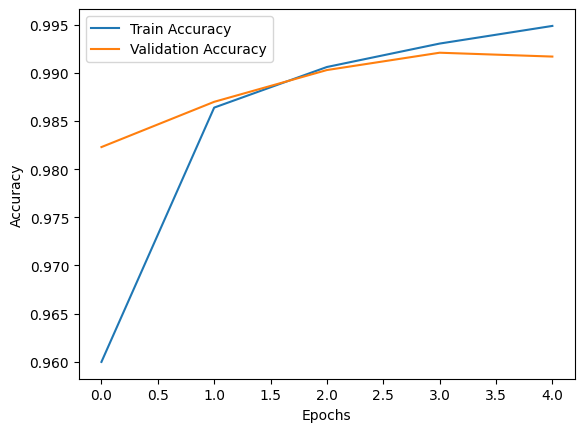

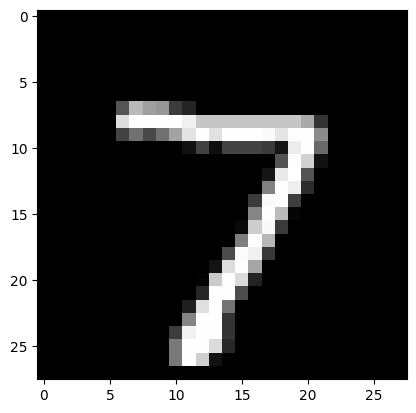

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Predicted Digit: 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
Predicted Digit: 7


In [12]:
#Build CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 output classes (digits 0-9)
])

#Compile Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train Model
history = model.fit(x_train, y_train, epochs=5, 
                    validation_data=(x_test, y_test))

#Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc*100:.2f}%")

#Plot Training History
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#Test on a single image
import numpy as np

index = 0  # Change index to test different images
plt.imshow(x_test[index].reshape(28,28), cmap='gray')
plt.show()

prediction = model.predict(x_test[index].reshape(1,28,28,1))
print("Predicted Digit:", np.argmax(prediction))
